In [1]:
"""Calibration figure: (A) flexible LOESS curve, (B) decile bins with patient-level bootstrap CI."""

import joblib
import logging
from pathlib import Path
import numpy as np
import numpy.typing as npt
from tqdm import tqdm
from xgboost import XGBClassifier
from keras.models import load_model
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt
from src.module.utils import load_config, get_peak_trough, process_meanbp, load_npy

In [2]:
def load_path(src_path, strategy="hypophetversion2"):
    pos_path = np.array(
        sorted(src_path.rglob(f"{strategy}_adj{config['adjacency']}_pos_*.npy"))
    )
    neg_path = np.array(
        sorted(src_path.rglob(f"{strategy}_adj{config['adjacency']}_neg_*.npy"))
    )
    return pos_path, neg_path


def load_dataset(pos_path, neg_path) -> tuple[npt.NDArray, npt.NDArray]:
    pos_cid = load_npy(pos_path[0])
    neg_cid = load_npy(neg_path[0])
    # env['pos_path'] : pos_lt
    pos_seg = load_npy(pos_path[2])
    neg_seg = load_npy(neg_path[1])
    pos_ts = load_npy(pos_path[3])
    neg_ts = load_npy(neg_path[2])
    pos_y, neg_y = np.ones(len(pos_seg)), np.zeros(len(neg_seg))
    X, y = np.vstack([pos_seg, neg_seg]), np.hstack([pos_y, neg_y])
    cid = np.hstack([pos_cid, neg_cid])
    ts = np.vstack([pos_ts, neg_ts])
    logging.info(f"load_dataset(pos/neg): {y.size}({pos_y.size}/{neg_y.size})")
    print(X.shape, y.shape, cid.shape, ts.shape)
    return cid, ts, X, y

In [3]:
def extract_lastmbp(arr, config):
    mbp = process_meanbp(arr.reshape(-1), config)
    mbp = np.unique(mbp[np.where(mbp != 0)])
    return mbp[-1]


def get_min_size(x, p, t):
    if x[p].size < x[t].size:
        min_size = x[p].size
    else:
        min_size = x[t].size
    return min_size


def summary_stat(arr):
    x = arr.reshape(-1)
    x_mean, x_std, x_median, x_min, x_max = (
        np.mean(x),
        np.std(x),
        np.median(x),
        np.min(x),
        np.max(x),
    )
    return x_mean, x_std, x_median, x_min, x_max


def slope_intercept(t, y):
    t = np.asarray(t, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    tm, ym = t.mean(), y.mean()
    dt = t - tm
    denom = (dt * dt).sum()
    if denom == 0:
        return np.nan, np.nan
    slope = (dt * (y - ym)).sum() / denom
    return slope, ym - (slope * tm)


def extract_feature(arr, config):
    feature = []
    p, t = get_peak_trough(arr, config["detection"])
    min_size = get_min_size(arr, p, t)
    mbp = process_meanbp(arr.reshape(-1), config)
    sbp, dbp, pp = arr[p], arr[t], arr[p][:min_size] - arr[t][:min_size]
    mbp = np.unique(mbp[np.where(mbp != 0)])

    sbp_stat = summary_stat(sbp)
    dbp_stat = summary_stat(dbp)
    pp_stat = summary_stat(pp)
    mbp_stat = summary_stat(mbp)
    trend_per_beat, _ = slope_intercept(np.arange(mbp.size), mbp)
    trend_per_sec = trend_per_beat * (mbp.size / 30.0)
    half = mbp.size // 2
    slope_per_beat, _ = slope_intercept(np.arange(mbp.size)[half:], mbp[half:])
    slope_per_sec = slope_per_beat * (mbp.size / 30.0)
    last_mbp = mbp[-1]

    feature.extend(
        [
            *sbp_stat,
            *dbp_stat,
            *pp_stat,
            *mbp_stat,
            trend_per_sec,
            slope_per_sec,
            last_mbp,
        ]
    )
    return feature


def scale_input(input) -> npt.NDArray:
    return input.astype(np.float32) / 200

In [4]:
def loess_calibration(y, p, frac=0.3, grid=None):
    """LOESS-smoothed observed rate as a function of predicted probability."""
    y = np.asarray(y, float)
    p = np.asarray(p, float)
    fitted = lowess(y, p, frac=frac, return_sorted=True)
    xs, ys = fitted[:, 0], np.clip(fitted[:, 1], 0, 1)
    if grid is None:
        grid = np.linspace(p.min(), p.max(), 200)
    return grid, np.interp(grid, xs, ys)


def binned_calibration(y, p, cid, n_bins=10, n_boot=2000, seed=42):
    """Decile bins: mean predicted, observed rate, and patient-level bootstrap CI."""
    y = np.asarray(y, float)
    p = np.asarray(p, float)
    cid = np.asarray(cid)

    edges = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    bin_id = np.digitize(p, edges[1:-1])

    pat_ids = np.unique(cid)
    idx_by_pat = {q: np.where(cid == q)[0] for q in pat_ids}
    rng = np.random.default_rng(seed)

    boot = np.full((n_boot, n_bins), np.nan)
    for b in range(n_boot):
        sampled = rng.choice(pat_ids, size=len(pat_ids), replace=True)
        idx = np.concatenate([idx_by_pat[q] for q in sampled])
        yb, bb = y[idx], bin_id[idx]
        for k in range(n_bins):
            m = bb == k
            if m.sum() > 0:
                boot[b, k] = yb[m].mean()

    out = []
    for k in range(n_bins):
        m = bin_id == k
        lo, hi = np.nanpercentile(boot[:, k], [2.5, 97.5])
        out.append(
            dict(mean_pred=p[m].mean(), obs=y[m].mean(), lo=lo, hi=hi, n=int(m.sum()))
        )
    return out


def plot_calibration(
    y, probs, cid, n_bins=10, n_boot=2000, frac=0.3, figsize=(11, 5), savepath=None
):
    """probs: dict of {model_name: predicted probability array}."""
    fig, axes = plt.subplots(
        1, 2, figsize=figsize, sharex=True, sharey=True, constrained_layout=True
    )
    colors = plt.cm.tab10(np.linspace(0, 1, 10))

    for ax in axes:
        ax.plot([0, 1], [0, 1], "k--", lw=1, zorder=0)
        ax.set_xlabel("Predicted probability")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    axes[0].set_ylabel("Observed frequency")
    axes[0].set_title("A. Flexible (LOESS) calibration")
    axes[1].set_title("B. Decile bins with 95% CI")

    for i, (name, p) in enumerate(probs.items()):
        c = colors[i % 10]
        g, s = loess_calibration(y, p, frac=frac)
        axes[0].plot(g, s, color=c, lw=1.8, label=name)

        bins = binned_calibration(y, p, cid, n_bins=n_bins, n_boot=n_boot)
        x = np.array([b["mean_pred"] for b in bins])
        o = np.array([b["obs"] for b in bins])
        err = np.vstack(
            [
                o - np.array([b["lo"] for b in bins]),
                np.array([b["hi"] for b in bins]) - o,
            ]
        )
        axes[1].errorbar(
            x + i * 0.004,
            o,
            yerr=err,
            fmt="o",
            ms=4,
            color=c,
            capsize=2,
            lw=1,
            label=name,
        )

    axes[0].legend(fontsize=8, loc="upper left")

    # predicted-probability distribution below panel A
    ax_hist = axes[0].inset_axes([0, -0.25, 1, 0.16])
    for i, (name, p) in enumerate(probs.items()):
        ax_hist.hist(
            p, bins=50, range=(0, 1), histtype="step", color=colors[i % 10], lw=1
        )
    ax_hist.set_yticks([])
    ax_hist.set_xlim(0, 1)
    ax_hist.set_xlabel("Predicted probability")

    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig, axes

In [5]:
config = load_config("../../config/conf.yaml")
data_path = Path(config["data_path"]).expanduser() / "mover"
model_path = Path(config["model_path"]).expanduser() / "revision_seed42"
pos_path, neg_path = load_path(data_path / "05.dataset_new")

In [6]:
cid, ts, X, y = load_dataset(pos_path, neg_path)
print(np.unique(cid).shape, X.shape, y.shape, sum(y == 1), sum(y == 0))

(25793, 3000) (25793,) (25793,) (25793, 3000)
(649,) (25793, 3000) (25793,) 9295 16498


In [7]:
X_feat = np.array([extract_feature(x, config) for x in tqdm(X, ncols=75)])
print(X_feat.shape)

100%|██████████████████████████████| 25793/25793 [00:08<00:00, 2906.60it/s]

(25793, 23)


In [8]:
X_s = scale_input(X)

In [9]:
loaded_lrpipe = joblib.load(model_path / "lrpipe_baseline.joblib")
loaded_xgb = XGBClassifier()
loaded_xgb.load_model(model_path / "xgb_baseline.json")
loaded_cnn = load_model(model_path / "cnn.model.keras")
loaded_resnet = load_model(model_path / "resnet.model.keras")
loaded_lstmfcn = load_model(model_path / "lstmfcn.model.keras")
loaded_inceptiontime = load_model(model_path / "inceptiontime.model.keras")

2026-10-09 11:44:30.234825: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5 Max
2026-10-09 11:44:30.234850: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2026-10-09 11:44:30.234857: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 53.76 GB
2026-10-09 11:44:30.234872: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-10-09 11:44:30.234882: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
probs = {
    "LR": loaded_lrpipe["model"].predict_proba(X_feat)[:, 1],
    "XGBoost": loaded_xgb.predict_proba(X_feat)[:, 1],
    "CNN": loaded_cnn.predict(X_s).reshape(-1),
    "ResNet": loaded_resnet.predict(X_s).reshape(-1),
    "LSTMFCN": loaded_lstmfcn.predict(X_s).reshape(-1),
    "InceptionTime": loaded_inceptiontime.predict(X_s).reshape(-1),
}

 22/807 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step 

2026-10-09 11:44:31.415630: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


807/807 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
807/807 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step
807/807 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
807/807 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step


/var/folders/2g/clmvrww15hzf0cp5zjmw2x0m0000gn/T/ipykernel_81762/2478578800.py:102: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


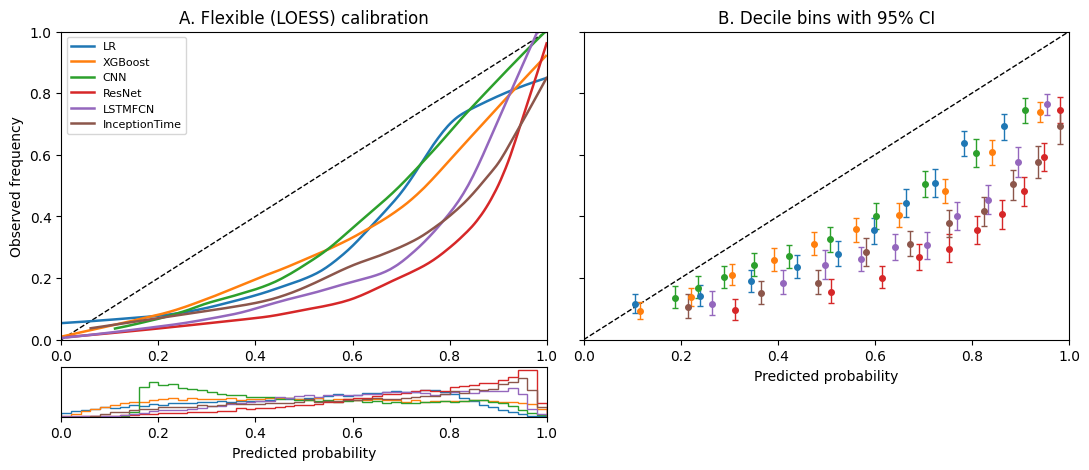

In [11]:
plot_calibration(y, probs, cid)
plt.show()

In [12]:
probs2 = {
    # "LR": loaded_lrpipe["model"].predict_proba(X_feat)[:, 1],
    "XGBoost": loaded_xgb.predict_proba(X_feat)[:, 1],
    "CNN": loaded_cnn.predict(X_s).reshape(-1),
    "ResNet": loaded_resnet.predict(X_s).reshape(-1),
    # "LSTMFCN": loaded_lstmfcn.predict(X_s).reshape(-1),
    # "InceptionTime": loaded_inceptiontime.predict(X_s).reshape(-1),
}

807/807 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
807/807 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step


/var/folders/2g/clmvrww15hzf0cp5zjmw2x0m0000gn/T/ipykernel_81762/2478578800.py:102: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


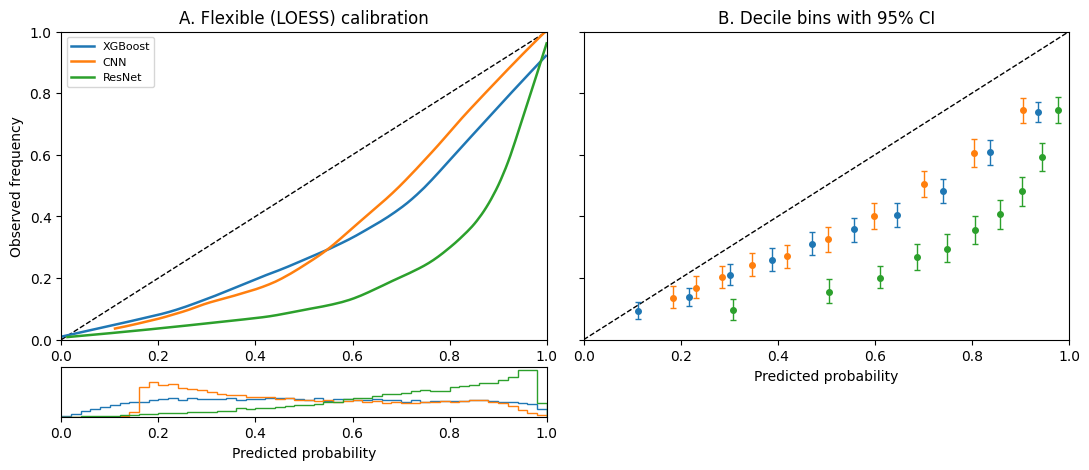

In [13]:
plot_calibration(y, probs2, cid)
plt.show()